In [1]:
import numpy as np
import scanpy as sc
import seaborn as sns
from scipy.stats import median_abs_deviation
from matplotlib import pyplot as plt
import os
from scipy.spatial import cKDTree
from typing import Literal
import pandas as pd


In [2]:
import os

samples = []
donors = []
folder = "/nfs/data3/mopitas/mapra/cell_atlas_data/visium/"

for file in os.listdir(folder):
    if file.endswith(".h5ad"):
        file_path = os.path.join(folder, file)
        adata_temp = sc.read_h5ad(file_path)
        if "donor" in adata_temp.obs.columns:
            donors.extend(adata_temp.obs["donor"].unique())
            if "A61" in adata_temp.obs["donor"].unique():
                print(f"A61 found in {file}")

        if "sample" in adata_temp.obs.columns:
            samples.extend(adata_temp.obs["sample"].unique())

            if "HCAHeartST11445771" in adata_temp.obs["sample"].unique():
                print("HCAHeartST11445771 found")
            if "HCAHeartST11350194" in adata_temp.obs["sample"].unique():
                print("HCAHeartST11350194 found")

# Get unique samples
samples = list(set(samples))
donors = list(set(donors))
print(samples)
print(donors)


A61 found in visium-OCT_AVN_raw.h5ad
['HCAHeartST9383355', 'HCAHeartST13228105', 'HCAHeartST8795939', 'HCAHeartST8795940', 'HCAHeartST9383354', 'HCAHeartST11350377', 'HCAHeartST11290662', 'HCAHeartST10659160', 'HCAHeartST9383356', 'HCAHeartST11290658', 'HCAHeartST8795933', 'HCAHeartST8795935', 'HCAHeartST11290659', 'HCAHeartST9341984', 'HCAHeartST13233997', 'HCAHeartST10238253', 'HCAHeartST11290657', 'HCAHeartST10550730', 'HCAHeartST10238252', 'HCAHeartST13233996', 'HCAHeartST13233998', 'HCAHeartST13228106', 'HCAHeartST8795938', 'HCAHeartST12992075', 'HCAHeartST10238251', 'HCAHeartST9341983', 'HCAHeartST10550732', 'HCAHeartST8795934', 'HCAHeartST13233999', 'HCAHeartST9341982', 'HCAHeartST12992074', 'HCAHeartST8795936', 'HCAHeartST9383352', 'HCAHeartST13228103', 'HCAHeartST11350375', 'HCAHeartST9383358', 'HCAHeartST12992072', 'HCAHeartST8795937', 'HCAHeartST9383353']
['D3', 'D8', 'D5', 'AH1', 'AH5', 'AH2', 'AV1', 'A61', 'AV14', 'D6', 'AH6', 'D7']


In [ ]:

sc.settings.verbosity = 0
sc.settings.set_figure_params(
    dpi=80,
    facecolor="white",
    frameon=False,
)

filename = "/nfs/data3/mopitas/mapra/cell_atlas_data/visium/visium-OCT_AVN_raw.h5ad"
adata = sc.read_h5ad(filename)

In [5]:
adata.obs["donor"].value_counts()

donor
A61    10278
AH2     7999
AH6     2942
AH1     2807
Name: count, dtype: int64

In [6]:
adata.obs["sample"].value_counts()

sample
HCAHeartST12992074    4521
HCAHeartST12992075    3478
HCAHeartST11290662    3153
HCAHeartST13228103    2942
HCAHeartST11350377    2807
HCAHeartST11290658    2697
HCAHeartST11290659    2338
HCAHeartST11290657    2090
Name: count, dtype: int64

In [10]:

adata = adata[adata.obs["in_tissue"] == True, :]
adata.var_names_make_unique()

In [11]:
adata.var_names.str.startswith("MT-").sum()

np.int64(0)

In [12]:
adata.obs["mt_frac"].describe()

count    24026.000000
mean         0.299241
std          0.083866
min          0.041824
25%          0.239414
50%          0.300417
75%          0.361024
max          0.613035
Name: mt_frac, dtype: float64

In [13]:
def modified_z_score(values, s=1.4826):
    """
    Compute modified z-scores as in the R `spatialEco::outliers` function.
    Median Absolute Deviation (MAD) based robust z-score.
    """
    values = np.array(values, dtype=float)

    median_val = np.median(values)
    mad_val = np.median(np.abs(values - median_val))
    if mad_val == 0:
        return np.zeros_like(values)
    return 0.6745 * (values - median_val) / mad_val


def local_outliers(
    adata,
    metric: str = "n_genes_by_counts",
    direction: Literal["lower", "higher"] = "lower",
    n_neighbors: int = 36,
    samples: str = "Sample_ID",
    cutoff: float = 3
):
    """
    Detect local outliers in spatial transcriptomics data.

    Parameters
    ----------
    adata : AnnData
        AnnData object with `obsm['spatial']` and QC metric in `obs`.
    metric : str
        Column in adata.obs to use for outlier detection.
    direction : {"lower", "higher"}
        Whether to detect low or high outliers.
    n_neighbors : int
        Number of nearest neighbors to consider.
    samples : str
        Column in adata.obs containing sample IDs (batch).
    cutoff : float
        Modified z-score threshold for calling outliers.

    Returns
    -------
    AnnData
        Updated AnnData with new columns:
        - `<metric>_z`: modified z-scores
        - `<metric>_outliers`: boolean array for detected outliers
    """
    # Loop through each unique sample IDs
    all_results = []
    for sample_id in adata.obs[samples].unique():
        # Subset the data for the current sample
        subset = adata.obs[samples] == sample_id
        adata_sub = adata[subset].copy()

        # Create a list of spatial coordinates and qc features
        coords = np.array(adata_sub.obsm["spatial"])
        values = adata_sub.obs[metric].values

         # Find nearest neighbors (excluding self)
        tree = cKDTree(coords)
        _, idx = tree.query(coords, k=n_neighbors + 1)
        idx = idx[:, 1:]  # remove self from neighbor list
        
        # idx[i, j] = index of the j-th nearest neighbor of spot i
        
        # get neighborhood metrics (including self) for each spot
        z_scores = []
        for i in range(idx.shape[0]):
            neighbor_vals = values[np.concatenate(([i], idx[i]))]
            z = modified_z_score(neighbor_vals)[0]  # score for the central spot
            z_scores.append(z)
        
        # find outliers based on cutoff, store in outlier_flags
        z_scores = np.array(z_scores)
        outlier_flags = np.zeros_like(z_scores, dtype=bool)

        if direction == "higher":
            outlier_flags = z_scores > cutoff
        elif direction == "lower":
            outlier_flags = z_scores < -cutoff

        # save z-scores and outliers
        result_df = pd.DataFrame({
            f"{metric}_z": z_scores,
            f"{metric}_outliers": outlier_flags
        }, index=adata_sub.obs.index)

        all_results.append(result_df)
        
    # Merge results into main AnnData.obs
    results_df = pd.concat(all_results)
    adata.obs = adata.obs.join(results_df)

    return adata

In [37]:
adata.obs["log1p_total_counts"]

spot_id
HCAHeartST11290657_AAACAACGAATAGTTC-1    8.034955
HCAHeartST11290657_AAACAATCTACTAGCA-1    6.979145
HCAHeartST11290657_AAACAGAGCGACTCCT-1    7.034388
HCAHeartST11290657_AAACCGGAAATGTTAA-1    7.087574
HCAHeartST11290657_AAACCGGGTAGGTACC-1    6.695799
                                           ...   
HCAHeartST13228103_TTGTTCAGTGTGCTAC-1    8.996900
HCAHeartST13228103_TTGTTCTAGATACGCT-1    7.706613
HCAHeartST13228103_TTGTTGTGTGTCAAGA-1    8.124150
HCAHeartST13228103_TTGTTTCACATCCAGG-1    6.455199
HCAHeartST13228103_TTGTTTCCATACAACT-1    9.247828
Name: log1p_total_counts, Length: 22723, dtype: float32

In [38]:
adata.obs

,in_tissue,array_row,array_col,sample,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,...,qc_detected,qc_mito_prop,global_outliers,log1p_total_counts_z,log1p_total_counts_outliers,log1p_n_genes_by_counts_z,log1p_n_genes_by_counts_outliers,mt_frac_z,mt_frac_outliers,local_outliers
spot_id,,,,,,,,,,,,,,,,,,,,,
HCAHeartST11290657_AAACAACGAATAGTTC-1,1,0,16,HCAHeartST11290657,1227,7.113142,3086.0,8.034955,45.268957,52.786779,...,False,False,False,0.315406,False,0.489640,False,-0.377682,False,False
HCAHeartST11290657_AAACAATCTACTAGCA-1,1,3,43,HCAHeartST11290657,571,6.349139,1073.0,6.979145,44.641193,54.426841,...,False,False,False,4.827762,False,2.423478,False,-1.151219,False,False
HCAHeartST11290657_AAACAGAGCGACTCCT-1,1,14,94,HCAHeartST11290657,642,6.466145,1134.0,7.034388,38.624339,47.795414,...,False,False,False,1.254789,False,1.298121,False,0.307953,False,False
HCAHeartST11290657_AAACCGGAAATGTTAA-1,1,54,124,HCAHeartST11290657,546,6.304449,1196.0,7.087574,51.421405,60.200669,...,False,False,False,-0.342328,False,-0.142582,False,-0.834039,False,False
HCAHeartST11290657_AAACCGGGTAGGTACC-1,1,42,28,HCAHeartST11290657,495,6.206576,808.0,6.695799,37.747525,50.123762,...,False,False,False,0.660725,False,0.747714,False,-0.927321,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
HCAHeartST13228103_TTGTTCAGTGTGCTAC-1,1,24,64,HCAHeartST13228103,1980,7.591357,8077.0,8.996900,57.583261,63.154637,...,False,False,False,-0.203833,False,-0.421723,False,1.044458,False,False
HCAHeartST13228103_TTGTTCTAGATACGCT-1,1,21,3,HCAHeartST13228103,856,6.753438,2222.0,7.706613,51.260126,58.955896,...,False,False,False,-0.565909,False,-0.556450,False,1.151758,False,False
HCAHeartST13228103_TTGTTGTGTGTCAAGA-1,1,31,77,HCAHeartST13228103,1315,7.182352,3374.0,8.124150,46.058091,53.764078,...,False,False,False,-0.049804,False,-0.156636,False,0.255096,False,False


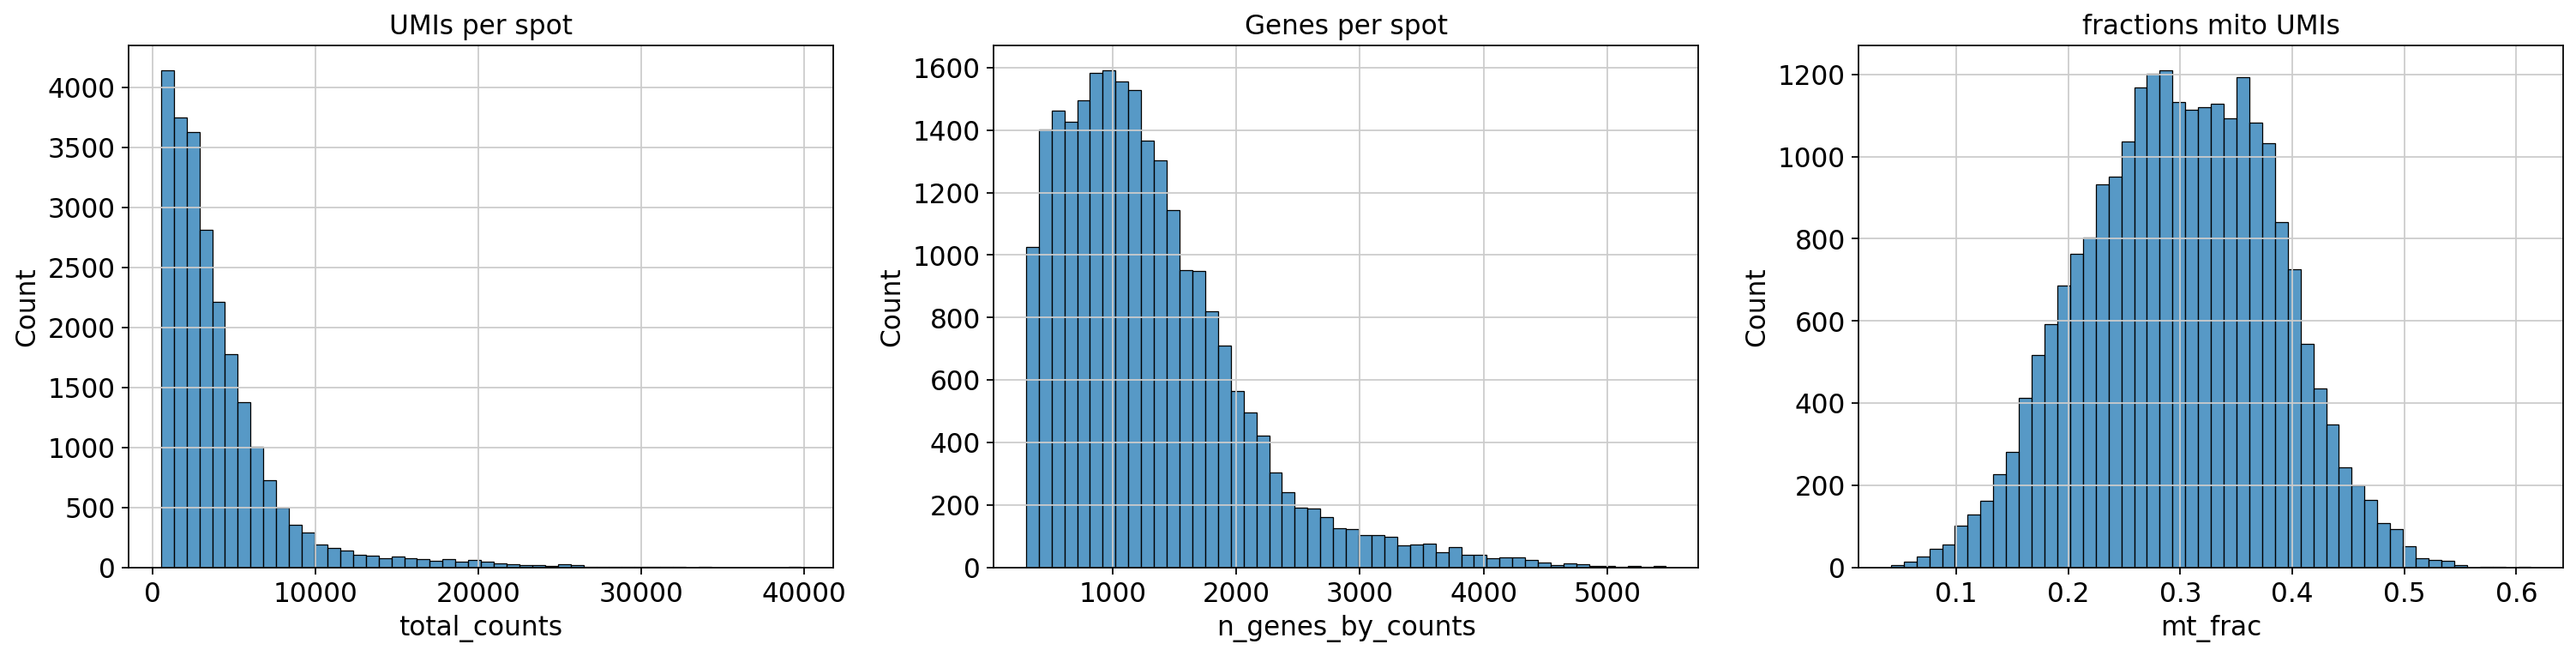

In [15]:

#  plot QC metrics
fig, axes = plt.subplots(1, 3, figsize=(19, 5))

sns.histplot(adata.obs["total_counts"], bins=50, kde=False, ax=axes[0])
axes[0].set_title("UMIs per spot")

sns.histplot(adata.obs["n_genes_by_counts"], bins=50, kde=False, ax=axes[1])
axes[1].set_title("Genes per spot")

sns.histplot(adata.obs["mt_frac"], bins=50, kde=False, ax=axes[2])
axes[2].set_title("fractions mito UMIs")

plt.tight_layout()
plt.show()

In [25]:
# global outlier detection
adata.obs["qc_lib_size"] = (adata.obs["total_counts"] < 500) 
adata.obs["qc_detected"] = (adata.obs["n_genes_by_counts"] < 300) 
adata.obs["qc_mito_prop"] = adata.obs["mt_frac"] > 0.6

adata.obs["global_outliers"] = (adata.obs["qc_lib_size"].values) | (adata.obs["qc_detected"].values) | (adata.obs["qc_mito_prop"].values)

# local outlier detection
local_outliers(adata, "log1p_total_counts", "lower", 3, samples="sample")
local_outliers(adata, "log1p_n_genes_by_counts", "lower", 3, samples="sample")
local_outliers(adata, "mt_frac", "higher", 3, samples="sample")

adata.obs["local_outliers"] = (adata.obs["log1p_total_counts_outliers"].values) | (adata.obs["log1p_n_genes_by_counts_outliers"].values) | (adata.obs["mt_frac_outliers"].values)


ValueError: columns overlap but no suffix specified: Index(['log1p_total_counts_z', 'log1p_total_counts_outliers'], dtype='object')

In [22]:
len(set(list(adata[adata.obs["donor"]=="A61"].uns["spatial"].keys())))

50

/tmp/ipykernel_1287291/766235392.py:3: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/tmp/ipykernel_1287291/766235392.py:14: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


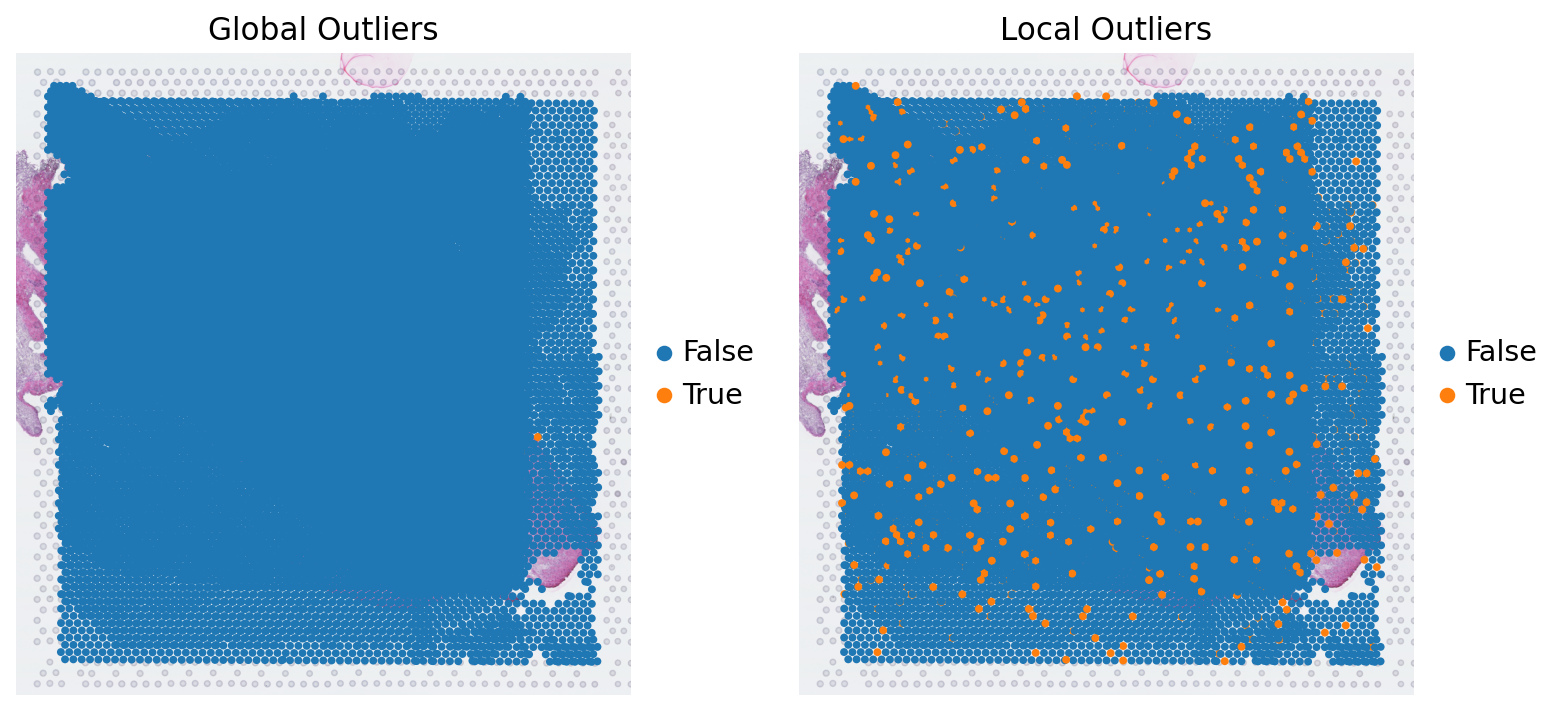

In [27]:

fig, axes = plt.subplots(1, 2, figsize=(10, 5))  # 1 row, 2 columns

sc.pl.spatial(
    adata,
    color="global_outliers",
    #library_id=["HCAHeartST11350194", "HCAHeartST11445771"],
    library_id="HCAHeartST10238251",
    size=1.5,
    title="Global Outliers",
    ax=axes[0],
    show=False
)

sc.pl.spatial(
    adata,
    color="local_outliers",
    library_id="HCAHeartST10238251",
    size=1.5,
    title="Local Outliers",
    ax=axes[1],
    show=False
)

plt.tight_layout()
plt.show()

In [28]:
adata = adata[(~adata.obs.global_outliers) & (~adata.obs.local_outliers)].copy()


In [34]:

adata.write_h5ad(filename.replace(".h5ad", "_filtered.h5ad"))

/nfs/home/students/m.back/.conda/envs/mzb_python3.11/lib/python3.11/site-packages/anndata/_io/utils.py:243: FutureWarning: Forward slashes will be disallowed in h5 stores in the next minor release
  return func(*args, **kwargs)


TODO: 
- save plots
- clean andata (e.g. remove added columns and maybe other columns ('B-cells', 'CAFs', 'Cancer Epithelial', 'Endothelial', 'Myeloid', 'Normal Epithelial', 'PVL', 'T-cells') to save space)